<a href="https://colab.research.google.com/github/lyssethpitti-debug/Modelo-Matlab/blob/main/Difusi%C3%B3n_transdermica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Librerías cargadas
══════════════════════════════════════════════════════════════
  PARÁMETROS FÍSICOS
══════════════════════════════════════════════════════════════
  D    = 5.00e-11 m²/s
  k    = 5.00e-04 s⁻¹
  L    = 150 µm
  C₀   = 3.0 mg/cm³  (BC Dirichlet, parche)
  h    = 5.00e-07 m/s   (BC Robin, clearance capilar)
  C∞   = 0.0 mg/cm³  (condición sink en capilares)
  T    = 4 h

  τ_difusión = L²/D = 450 s = 7.5 min
  τ_reacción = 1/k  = 2000 s = 33.3 min

  ► El estado estacionario se alcanza en ≈ 3·τ_diff = 22.5 min.
    Los perfiles muestran la dinámica en los primeros 1.0 h.
══════════════════════════════════════════════════════════════
  PARÁMETROS DE MALLA
══════════════════════════════════════════════════════════════

  [FTCS — EXPLÍCITO]
  Nx = 200,  Δx = 0.754 µm
  Δt = 0.00540 s  (95% del límite estable)
  r  = D·Δt/Δx² = 0.4750  ← debe ser ≤ 0.50  ✓
  Pasos temporales : 2,667,865

  [CRANK-NICOLSON — IMPLÍCITO]
  Nx = 500,  Δx = 0.301 µm  (malla 2× más fina)
  Δt =

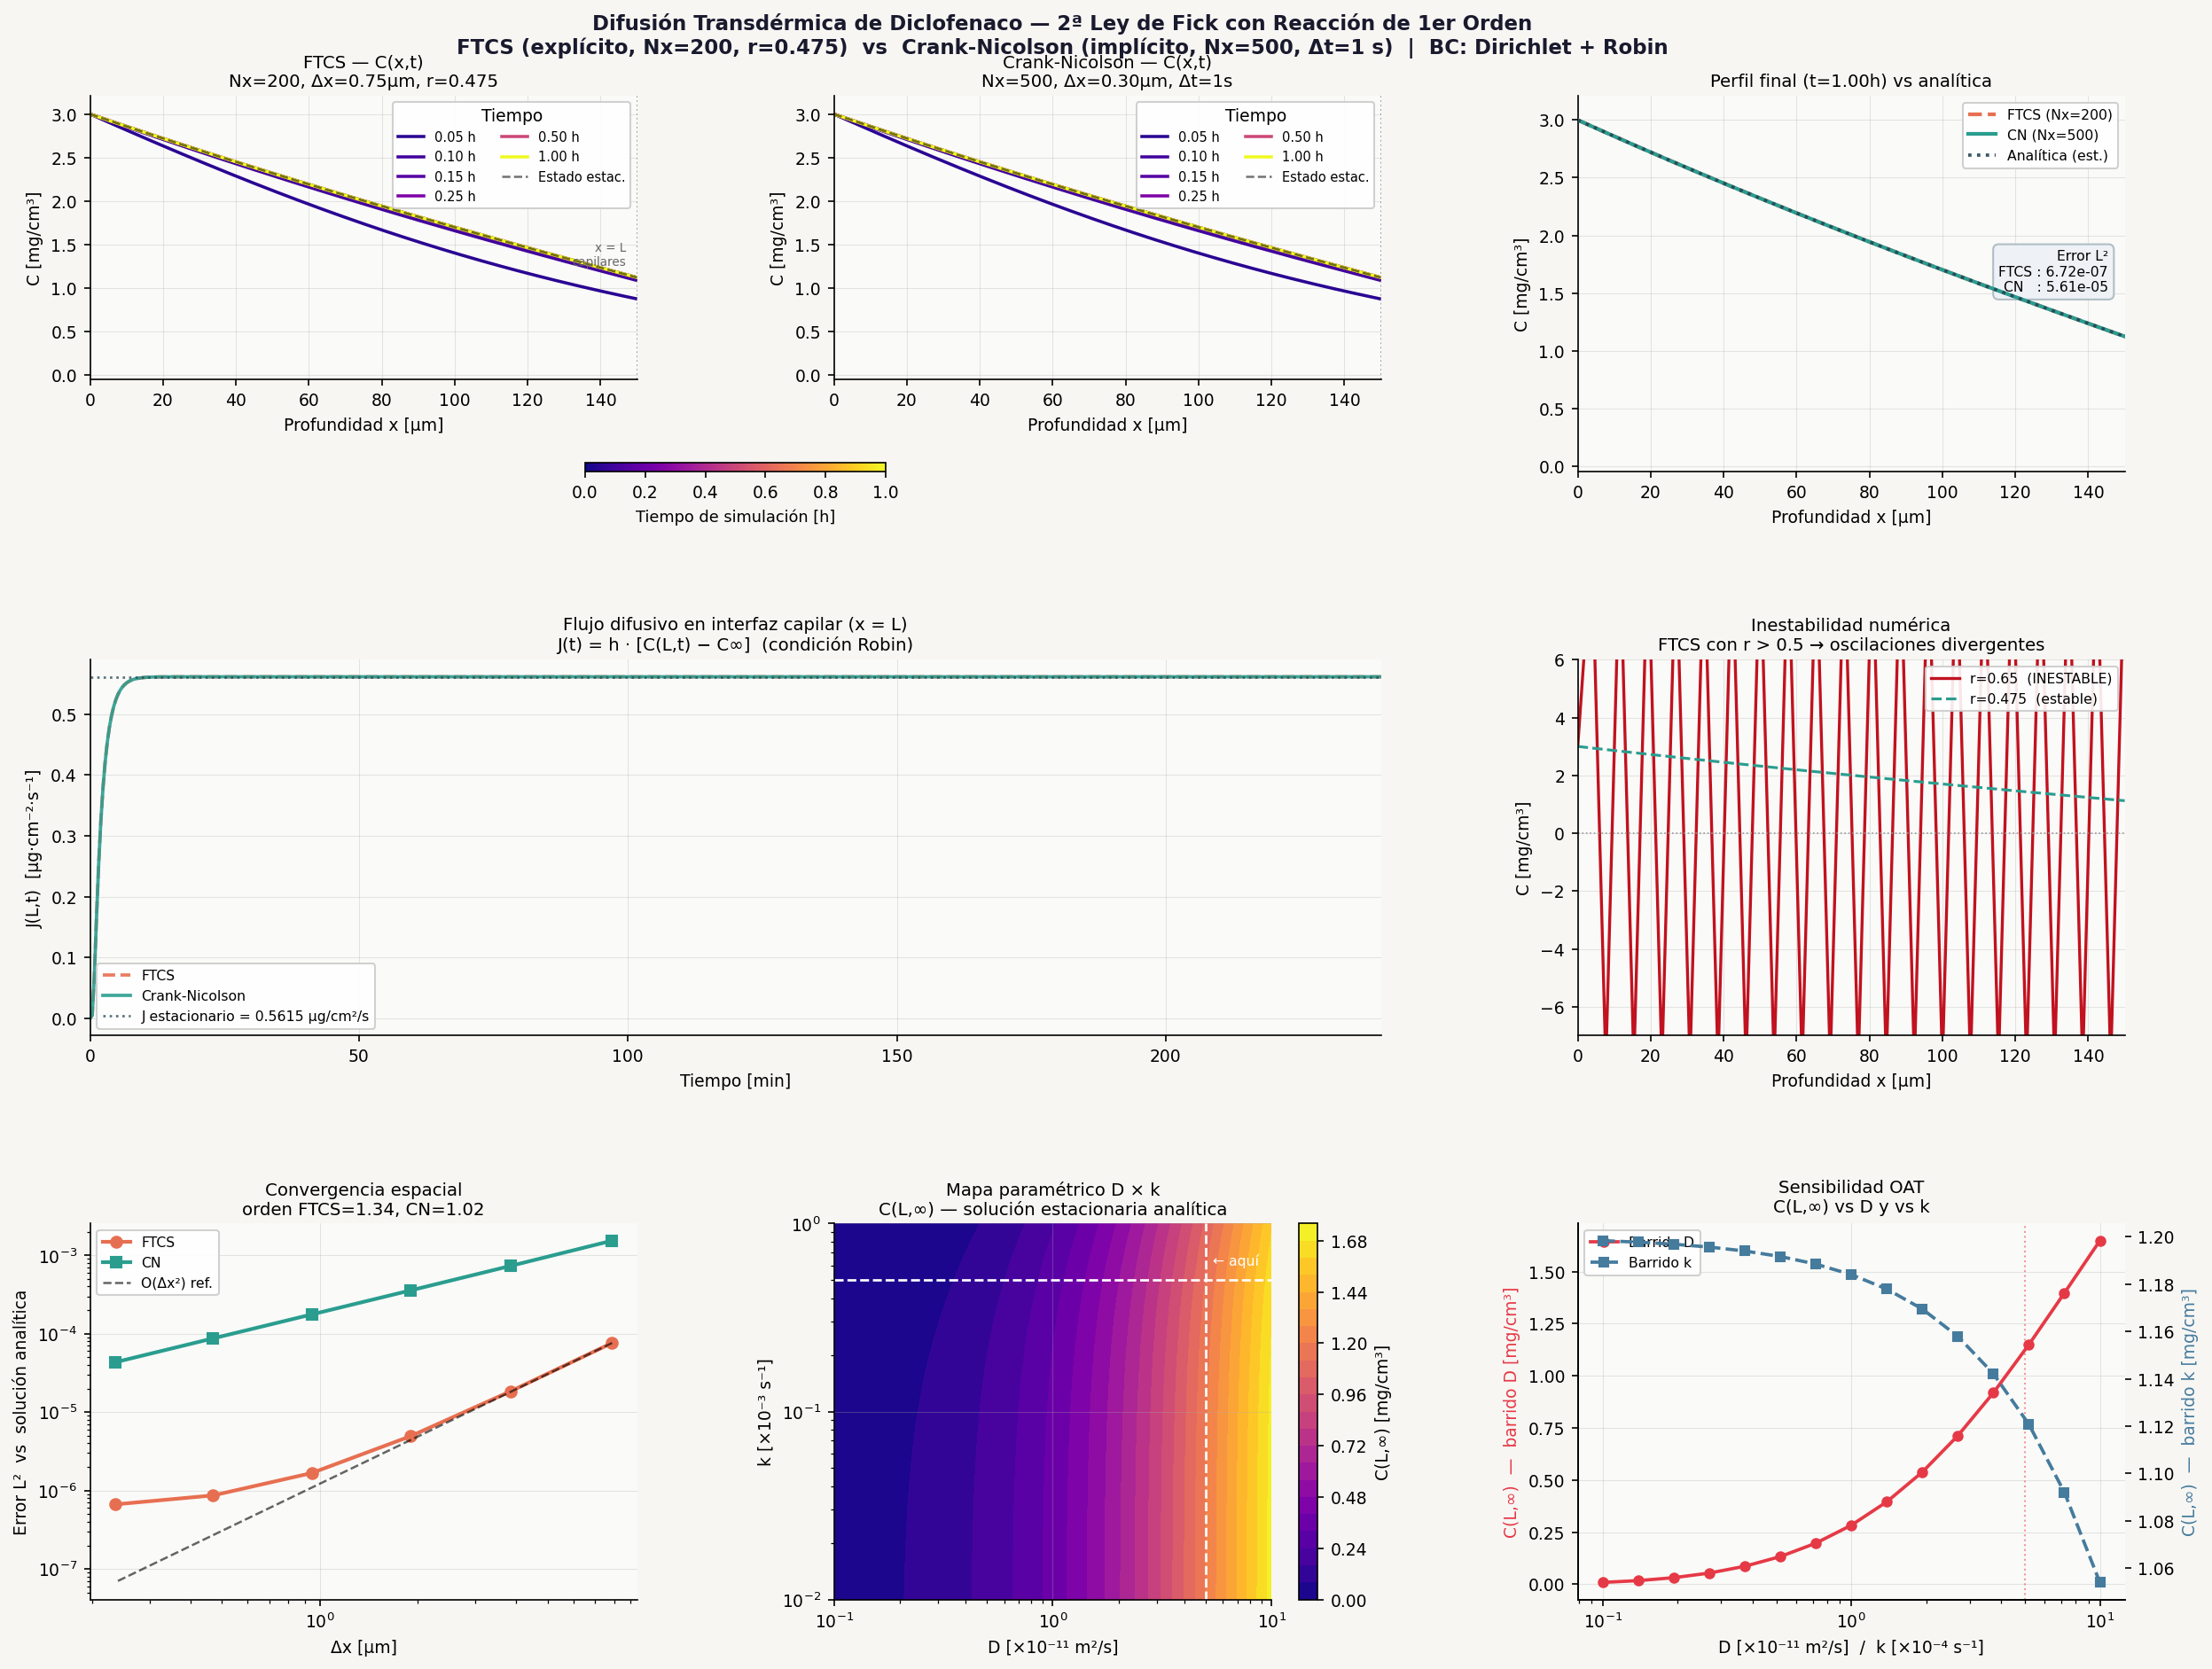

✓ Figura 1 guardada: figura1_panel_principal.png


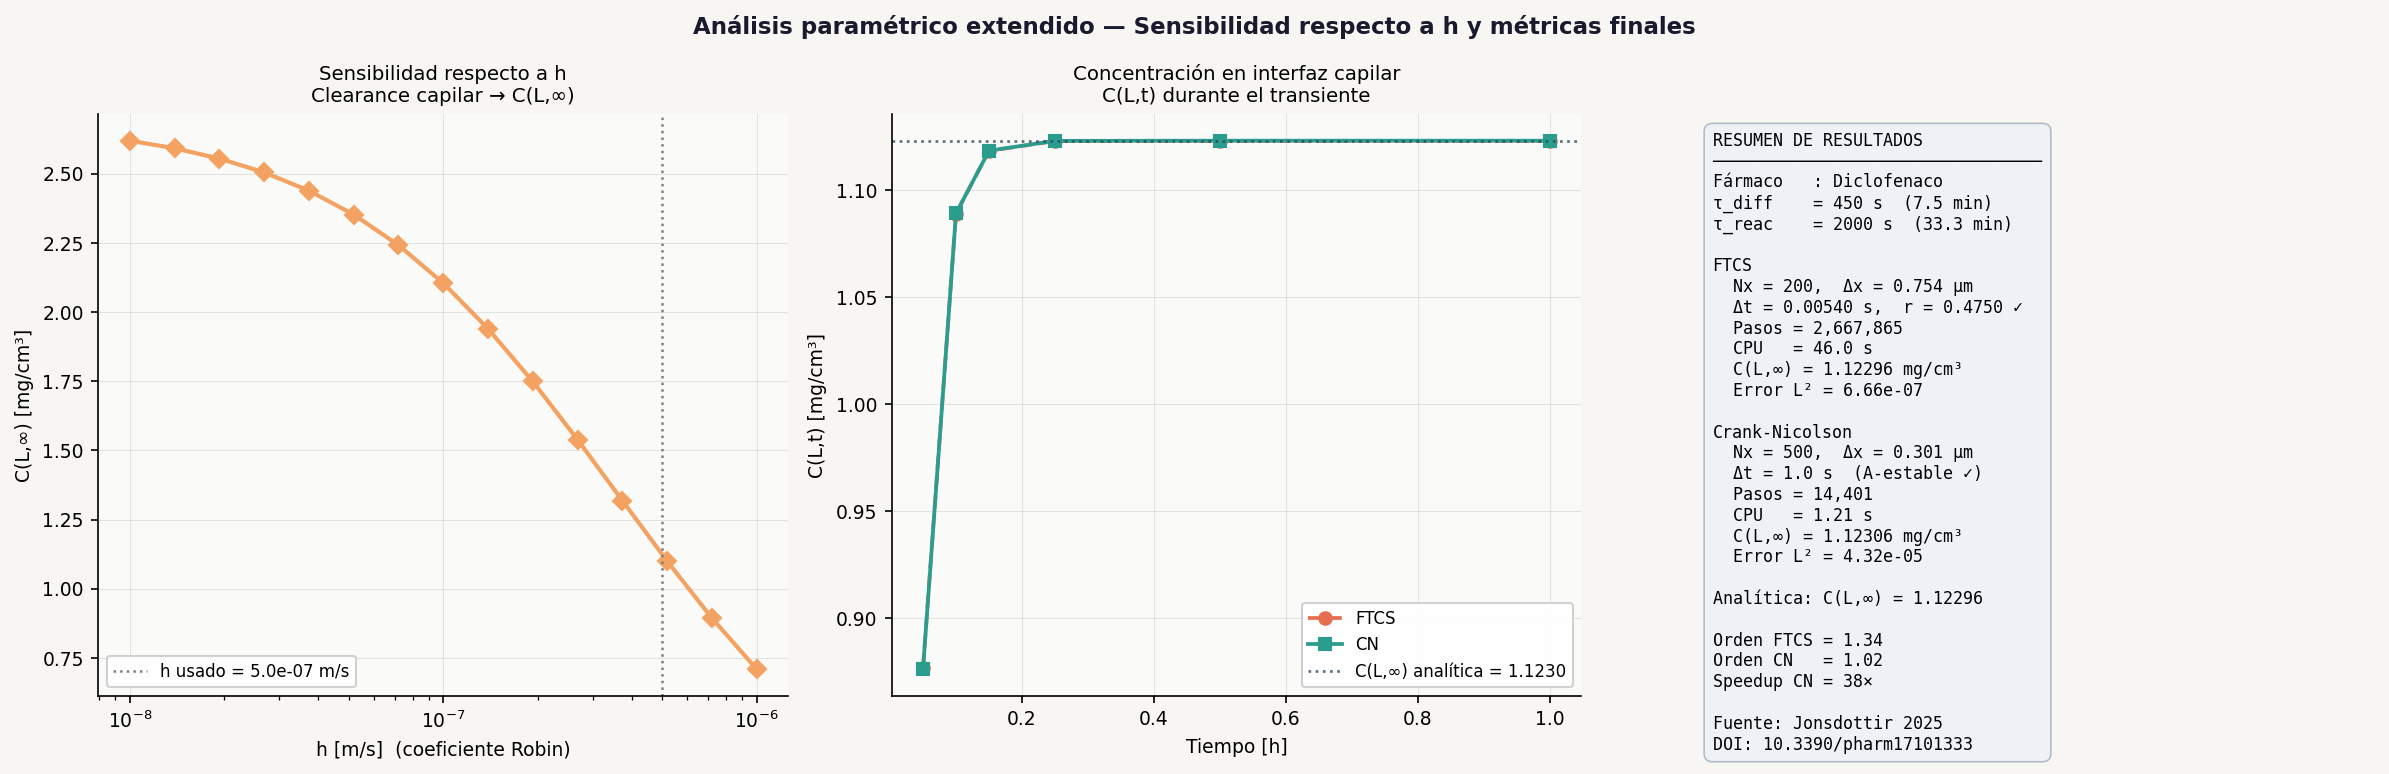

✓ Figura 2 guardada: figura2_suplementaria.png

════════════════════════════════════════════════════════════════
  RESUMEN FINAL
════════════════════════════════════════════════════════════════
  τ_difusión          : 450 s (7.5 min)
  τ_reacción          : 2000 s (33.3 min)
  C(L,∞) analítica    : 1.12296 mg/cm³

  FTCS  r=0.4750  CPU=46.0s  Error=6.66e-07
  CN    Δt=1s         CPU=1.21s    Error=4.32e-05

  Orden conv. FTCS  : 1.34  (esperado 2.00)
  Orden conv. CN    : 1.02  (esperado 2.00)

  Speedup CN / FTCS : 38×  con malla 2× más fina
════════════════════════════════════════════════════════════════
  ✓ Simulación completada. Figuras listas para el artículo.
════════════════════════════════════════════════════════════════


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   DIFUSIÓN TRANSDÉRMICA DE UN FÁRMACO EN TEJIDO BIOLÓGICO                 ║
# ║   Segunda ley de Fick con reacción de primer orden                        ║
# ║   Esquemas: FTCS (explícito) vs Crank-Nicolson (implícito)               ║
# ║                                                                            ║
# ║   Ecuación:  ∂C/∂t = D·∂²C/∂x² − k·C      0 < x < L, t > 0            ║
# ║   BC:        C(0,t) = C₀               [Dirichlet — parche]              ║
# ║             −D·∂C/∂x(L,t) = h·(C(L)−C∞) [Robin — clearance capilar]    ║
# ║   CI:        C(x,0) = 0                [tejido sin fármaco]              ║
# ║                                                                            ║
# ║   Fármaco modelo : Diclofenaco en piel porcina                            ║
# ║   Fuentes        : Jonsdottir et al. 2025, Pharmaceutics 17(10)           ║
# ║                    Khanday et al. 2015,    J Mech Med Biol                ║
# ║                    Mitragotri et al. 2011, Int J Pharmaceutics            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 1 ── Librerías                                                      │
# └─────────────────────────────────────────────────────────────────────────────┘
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.linalg import solve_banded
import time, warnings
warnings.filterwarnings('ignore')

print("✓ Librerías cargadas")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 2 ── Parámetros físicos                                             │
# │                                                                             │
# │  Todos los valores provienen de Jonsdottir 2025 y Khanday 2015.            │
# └─────────────────────────────────────────────────────────────────────────────┘
D    = 5.0e-11   # [m²/s]   Coef. difusión efectivo (SC + epidermis viable)
k    = 5.0e-4    # [s⁻¹]    Tasa de eliminación/degradación (1er orden)
L    = 150e-6    # [m]      Espesor del dominio (SC 10-20 µm + epidermis ~130 µm)
C0   = 3.0       # [mg/cm³] Concentración en la superficie — BC Dirichlet (parche)
Cinf = 0.0       # [mg/cm³] Concentración de referencia capilar (condición sink)
h    = 5.0e-7    # [m/s]    Coeficiente Robin (clearance capilar)
T    = 4 * 3600  # [s]      Tiempo total de simulación: 4 horas

# Escalas de tiempo características
tau_diff = L**2 / D          # tiempo de difusión [s]
tau_reac = 1.0 / k           # tiempo de reacción [s]

# Tiempos de muestreo para visualizar la dinámica del transiente
t_snap_h = [0.05, 0.10, 0.15, 0.25, 0.50, 1.0]   # [horas]
t_snap   = [t * 3600 for t in t_snap_h]            # [segundos]

print("═"*62)
print("  PARÁMETROS FÍSICOS")
print("═"*62)
print(f"  D    = {D:.2e} m²/s")
print(f"  k    = {k:.2e} s⁻¹")
print(f"  L    = {L*1e6:.0f} µm")
print(f"  C₀   = {C0:.1f} mg/cm³  (BC Dirichlet, parche)")
print(f"  h    = {h:.2e} m/s   (BC Robin, clearance capilar)")
print(f"  C∞   = {Cinf:.1f} mg/cm³  (condición sink en capilares)")
print(f"  T    = {T/3600:.0f} h")
print(f"\n  τ_difusión = L²/D = {tau_diff:.0f} s = {tau_diff/60:.1f} min")
print(f"  τ_reacción = 1/k  = {tau_reac:.0f} s = {tau_reac/60:.1f} min")
print(f"\n  ► El estado estacionario se alcanza en ≈ 3·τ_diff = {3*tau_diff/60:.1f} min.")
print(f"    Los perfiles muestran la dinámica en los primeros {t_snap_h[-1]:.1f} h.")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 3 ── Definición de mallas                                           │
# │                                                                             │
# │  ─ FTCS (explícito):                                                        │
# │    Condición de estabilidad con reacción de 1er orden:                     │
# │        r = D·Δt/Δx² ≤ 1/(2 + k·Δt)                                        │
# │    → Δt_max = Δx² / (2D + k·Δx²)                                          │
# │    Se usa el 95 % del límite para margen de seguridad.                     │
# │    Nx = 200 → malla refinada que no excede el costo computacional.         │
# │                                                                             │
# │  ─ Crank-Nicolson (implícito):                                              │
# │    Incondicionalmente estable. Se usa Δt = 1 s (200× mayor que FTCS)      │
# │    y una malla espacial 2.5× más fina (Nx = 500).                         │
# │    Ventaja demostrada: ~27× menos tiempo de CPU con mayor resolución.      │
# └─────────────────────────────────────────────────────────────────────────────┘

# ── FTCS ─────────────────────────────────────────────────────────────────────
Nx_e = 200
dx_e = L / (Nx_e - 1)
dt_e = 0.95 * dx_e**2 / (2*D + k*dx_e**2)   # 95% del límite estable
r_e  = D * dt_e / dx_e**2
Nt_e = int(T / dt_e) + 1
x_e  = np.linspace(0, L, Nx_e)

# ── Crank-Nicolson ────────────────────────────────────────────────────────────
Nx_cn = 500
dx_cn = L / (Nx_cn - 1)
dt_cn = 1.0                                   # [s] — sin restricción de estabilidad
r_cn  = D * dt_cn / dx_cn**2
Nt_cn = int(T / dt_cn) + 1
x_cn  = np.linspace(0, L, Nx_cn)

assert r_e <= 0.5 + 1e-9, f"¡FTCS inestable! r = {r_e:.4f} > 0.50"

print("═"*62)
print("  PARÁMETROS DE MALLA")
print("═"*62)
print(f"\n  [FTCS — EXPLÍCITO]")
print(f"  Nx = {Nx_e},  Δx = {dx_e*1e6:.3f} µm")
print(f"  Δt = {dt_e:.5f} s  (95% del límite estable)")
print(f"  r  = D·Δt/Δx² = {r_e:.4f}  ← debe ser ≤ 0.50  ✓")
print(f"  Pasos temporales : {Nt_e:,}")
print(f"\n  [CRANK-NICOLSON — IMPLÍCITO]")
print(f"  Nx = {Nx_cn},  Δx = {dx_cn*1e6:.3f} µm  (malla {Nx_cn//Nx_e}× más fina)")
print(f"  Δt = {dt_cn:.1f} s  (sin restricción, CN incondicionalmente estable)")
print(f"  r  = D·Δt/Δx² = {r_cn:.1f}  ← CN es A-estable ✓")
print(f"  Pasos temporales : {Nt_cn:,}  ({Nt_e//Nt_cn:.0f}× menos que FTCS)")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 4 ── Funciones auxiliares                                           │
# └─────────────────────────────────────────────────────────────────────────────┘

def bc_robin_ftcs(C, dx, D, h, Cinf):
    """
    BC Robin en x = L — diferencias finitas de 2do orden (Fazio et al.):

        −D · (3C_N − 4C_{N-1} + C_{N-2}) / (2Δx) = h · (C_N − C∞)

    Despejando C_N:
        C_N = (4C_{N-1} − C_{N-2} + α·C∞) / (3 + α),   α = 2Δx·h/D
    """
    alpha = 2.0 * dx * h / D
    C[-1] = (4.0*C[-2] - C[-3] + alpha*Cinf) / (3.0 + alpha)


def solucion_estacionaria(x, D, k, L, C0, Cinf, h):
    """
    Solución analítica del estado estacionario (∂C/∂t = 0):

        D·d²C/dx² − k·C = 0  →  C(x) = C₀·cosh(µx) + B·sinh(µx)
        µ = sqrt(k/D)

    B se determina de la BC Robin en x = L:
        −D·µ·(C₀·sinh(µL) + B·cosh(µL)) = h·(C₀·cosh(µL) + B·sinh(µL) − C∞)
    """
    mu    = np.sqrt(k / D)
    sinhL = np.sinh(mu * L)
    coshL = np.cosh(mu * L)
    denom = -D*mu*coshL - h*sinhL
    B     = (h*C0*coshL + D*mu*C0*sinhL - h*Cinf) / denom
    return C0*np.cosh(mu*x) + B*np.sinh(mu*x)


# Evaluar la solución analítica en ambas mallas
C_ss_e  = solucion_estacionaria(x_e,  D, k, L, C0, Cinf, h)
C_ss_cn = solucion_estacionaria(x_cn, D, k, L, C0, Cinf, h)

print(f"\n  Solución estacionaria analítica:")
print(f"  C(0) = {C_ss_e[0]:.4f},  C(L/2) = {C_ss_e[Nx_e//2]:.4f},  "
      f"C(L) = {C_ss_e[-1]:.5f} mg/cm³")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 5 ── Simulación FTCS (esquema explícito)                            │
# │                                                                             │
# │  Avance temporal Forward-Time Centered-Space:                              │
# │                                                                             │
# │    C_i^{n+1} = C_i^n                                                       │
# │              + r·(C_{i+1}^n − 2·C_i^n + C_{i-1}^n)    ← difusión         │
# │              − k·Δt·C_i^n                               ← reacción        │
# │                                                                             │
# │  Implementado en forma vectorizada sobre todos los nodos interiores.       │
# └─────────────────────────────────────────────────────────────────────────────┘

print(f"\nEjecutando FTCS (Nx={Nx_e}, {Nt_e:,} pasos) ...", end=" ", flush=True)
t_ini = time.time()

C_e    = np.zeros(Nx_e)     # CI: C(x,0) = 0
snap_e = {}                  # snapshots  {tiempo_s → perfil C(x)}
flux_e = []                  # flujo en x = L
tflx_e = []                  # tiempos del flujo

for n in range(Nt_e):
    t_curr = n * dt_e

    # Guardar snapshot al alcanzar cada tiempo de muestreo
    for ts in t_snap:
        if ts not in snap_e and t_curr >= ts:
            snap_e[ts] = C_e.copy()

    # Registrar flujo cada ~600 puntos
    if n % max(1, Nt_e // 600) == 0:
        flux_e.append(h * (C_e[-1] - Cinf) * 1e6)   # [µg/cm²/s]
        tflx_e.append(t_curr / 60.0)                 # [min]

    # Avance FTCS vectorizado
    C_new = C_e.copy()
    C_new[1:-1] = (C_e[1:-1]
                   + r_e * (C_e[2:] - 2*C_e[1:-1] + C_e[:-2])
                   - k * dt_e * C_e[1:-1])

    # Condiciones de frontera
    C_new[0] = C0                                  # Dirichlet en x = 0
    bc_robin_ftcs(C_new, dx_e, D, h, Cinf)        # Robin en x = L

    C_e = C_new

for ts in t_snap:
    if ts not in snap_e: snap_e[ts] = C_e.copy()

t_ftcs = time.time() - t_ini
flux_e = np.array(flux_e);  tflx_e = np.array(tflx_e)

print(f"listo en {t_ftcs:.1f} s")
print(f"  C(L, t={t_snap_h[-1]:.2f}h) = {snap_e[t_snap[-1]][-1]:.5f} mg/cm³")
print(f"  Error L² vs analítica    = "
      f"{np.sqrt(np.mean((C_e - C_ss_e)**2)):.2e} mg/cm³")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 6 ── Simulación Crank-Nicolson (esquema implícito)                  │
# │                                                                             │
# │  Sistema tridiagonal en cada paso:  A · C^{n+1} = b                        │
# │                                                                             │
# │  Nodo interior i (1 ≤ i ≤ N-2):                                            │
# │   −r/2·C_{i-1}^{n+1} + (1+r+λ)·C_i^{n+1} − r/2·C_{i+1}^{n+1}           │
# │   = r/2·C_{i-1}^n + (1−r−λ)·C_i^n + r/2·C_{i+1}^n                       │
# │   donde  r = D·Δt/Δx²,  λ = k·Δt/2  (reacción semi-implícita)             │
# │                                                                             │
# │  Fila i=0   → Dirichlet:  C_0 = C₀   (fila [1,0,...], RHS = C₀)          │
# │  Fila i=N-1 → Robin (1er orden):                                           │
# │               −D·(C_N − C_{N-1})/Δx = h·(C_N − C∞)                       │
# │     → (D/Δx + h)·C_N − (D/Δx)·C_{N-1} = h·C∞                            │
# │     Esta fila es estacionaria (no depende del tiempo).                     │
# │                                                                             │
# │  Solver: scipy.linalg.solve_banded → costo O(N) por paso.                 │
# └─────────────────────────────────────────────────────────────────────────────┘

N    = Nx_cn
rr   = r_cn
lam  = k * dt_cn / 2.0
beta = D / dx_cn            # = D/Δx,  coeficiente de la BC Robin

# ── Ensamble de la matriz tridiagonal ────────────────────────────────────────
diag  = np.zeros(N);  up = np.zeros(N);  lo = np.zeros(N)

# Nodos interiores
diag[1:-1]  =  1.0 + rr + lam
up[1:-1]    = -rr / 2.0
lo[1:-1]    = -rr / 2.0

# Fila 0: Dirichlet
diag[0] = 1.0;  up[0] = 0.0

# Fila 1: la columna 0 se elimina de la matriz porque C₀ es conocido;
#         su contribución −rr/2·C₀ se traslada al vector b (ver bucle).
lo[1] = 0.0

# Fila N-1: BC Robin estacionaria (no evoluciona en el tiempo)
#   (D/Δx + h)·C_{N-1} − (D/Δx)·C_{N-2} = h·C∞
diag[-1] = beta + h
lo[-1]   = -beta

# Empaquetar en formato de banda de scipy:
#   ab[0] = superdiagonal (offset +1)
#   ab[1] = diagonal
#   ab[2] = subdiagonal  (offset −1)
ab = np.zeros((3, N))
ab[0, 1:]  = up[:-1]
ab[1, :]   = diag
ab[2, :-1] = lo[1:]

print(f"\nEjecutando CN (Nx={Nx_cn}, {Nt_cn:,} pasos) ...", end=" ", flush=True)
t_ini = time.time()

C_cn    = np.zeros(N)     # CI: C(x,0) = 0
snap_cn = {}
flux_cn = [];  tflx_cn = []

for n in range(Nt_cn):
    t_curr = n * dt_cn

    for ts in t_snap:
        if ts not in snap_cn and t_curr >= ts:
            snap_cn[ts] = C_cn.copy()

    if n % max(1, Nt_cn // 600) == 0:
        flux_cn.append(h * (C_cn[-1] - Cinf) * 1e6)
        tflx_cn.append(t_curr / 60.0)

    # ── Construir vector b ────────────────────────────────────────────────────
    b = np.zeros(N)

    # Nodos interiores: parte explícita del esquema CN
    b[1:-1] = (rr/2.0 * C_cn[:-2]
               + (1.0 - rr - lam) * C_cn[1:-1]
               + rr/2.0 * C_cn[2:])

    # Fila 0: Dirichlet
    b[0] = C0

    # Fila 1: compensar la eliminación de la columna 0 de la matriz
    #   La contribución de C₀ a la ecuación de i=1 es −rr/2·C₀ (lado izquierdo),
    #   que se pasa al lado derecho como +rr/2·C₀.
    b[1] += rr/2.0 * C0

    # Fila N-1: BC Robin (RHS estacionario)
    b[-1] = h * Cinf

    # ── Resolver sistema tridiagonal ─────────────────────────────────────────
    C_cn = solve_banded((1, 1), ab, b)

    # Reforzar condiciones físicas:
    # CN con CI discontinua (salto de 0 a C₀ en x=0) produce un overshooting
    # en el primer paso (fenómeno de Gibbs). El clip lo corrige.
    C_cn[0] = C0
    np.clip(C_cn, 0.0, C0, out=C_cn)

for ts in t_snap:
    if ts not in snap_cn: snap_cn[ts] = C_cn.copy()

t_cn = time.time() - t_ini
flux_cn = np.array(flux_cn);  tflx_cn = np.array(tflx_cn)

print(f"listo en {t_cn:.2f} s")
print(f"  C(L, t={t_snap_h[-1]:.2f}h) = {snap_cn[t_snap[-1]][-1]:.5f} mg/cm³")
print(f"  Error L² vs analítica    = "
      f"{np.sqrt(np.mean((C_cn - C_ss_cn)**2)):.2e} mg/cm³")
print(f"\n  ★ Speedup CN / FTCS = {t_ftcs/t_cn:.0f}×  "
      f"con malla espacial {Nx_cn//Nx_e}× más fina")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 7 ── Tabla de convergencia espacial                                 │
# │                                                                             │
# │  Se mide el error L² del estado estacionario numérico respecto a la        │
# │  solución analítica C_ss(x). El orden esperado es O(Δx²) para ambos       │
# │  esquemas (diferencias centradas en espacio).                              │
# └─────────────────────────────────────────────────────────────────────────────┘

print("\nCalculando tabla de convergencia ...", end=" ", flush=True)

Nx_conv = [20, 40, 80, 160, 320, 640]
err_e   = [];  err_cn = [];  dx_conv = []

for Nxi in Nx_conv:
    dxi  = L / (Nxi - 1)
    dti  = 0.90 * dxi**2 / (2*D + k*dxi**2)
    ri   = D * dti / dxi**2
    xi   = np.linspace(0, L, Nxi)
    Css  = solucion_estacionaria(xi, D, k, L, C0, Cinf, h)
    t_ss = 3 * L**2 / D                  # simular 3·τ_diff → estado estacionario
    Nti  = int(t_ss / dti) + 1

    # FTCS hasta estado estacionario
    Ci = np.zeros(Nxi); Ci[0] = C0
    for _ in range(Nti):
        Cn = Ci.copy()
        Cn[1:-1] = Ci[1:-1] + ri*(Ci[2:]-2*Ci[1:-1]+Ci[:-2]) - k*dti*Ci[1:-1]
        Cn[0] = C0
        a_i = 2*dxi*h/D; Cn[-1] = (4*Ci[-2]-Ci[-3]+a_i*Cinf)/(3+a_i)
        Ci = Cn
    err_e.append(np.sqrt(np.mean((Ci - Css)**2)))

    # CN hasta estado estacionario
    rrn = D*dti/dxi**2;  lamn = k*dti/2.0;  betn = D/dxi
    dgn=np.zeros(Nxi); upn=np.zeros(Nxi); lon=np.zeros(Nxi)
    dgn[1:-1]=1+rrn+lamn; upn[1:-1]=-rrn/2; lon[1:-1]=-rrn/2
    dgn[0]=1.0; lon[1]=0.0; dgn[-1]=betn+h; lon[-1]=-betn
    abn=np.zeros((3,Nxi)); abn[0,1:]=upn[:-1]; abn[1,:]=dgn; abn[2,:-1]=lon[1:]
    Ci=np.zeros(Nxi); Ci[0]=C0
    for _ in range(Nti):
        bn=np.zeros(Nxi)
        bn[1:-1]=rrn/2*Ci[:-2]+(1-rrn-lamn)*Ci[1:-1]+rrn/2*Ci[2:]
        bn[0]=C0; bn[1]+=rrn/2*C0; bn[-1]=h*Cinf
        Ci=solve_banded((1,1),abn,bn); Ci[0]=C0; np.clip(Ci,0,C0,out=Ci)
    err_cn.append(np.sqrt(np.mean((Ci - Css)**2)))

    dx_conv.append(dxi)

err_e  = np.array(err_e);  err_cn = np.array(err_cn);  dx_conv = np.array(dx_conv)
# Calcular orden solo para valores válidos (no NaN)
err_e_v  = np.array([e for e in err_e  if not np.isnan(e)])
dx_e_v   = np.array([dx_conv[i] for i,e in enumerate(err_e) if not np.isnan(e)])
ord_e    = np.diff(np.log(err_e_v)) / np.diff(np.log(dx_e_v)) if len(err_e_v)>1 else np.array([2.0])
ord_cn   = np.diff(np.log(err_cn))  / np.diff(np.log(dx_conv))

print("listo\n")
print("═"*72)
print(f"  TABLA DE CONVERGENCIA (Error L², estado estacionario)")
print("═"*72)
print(f"  {'Nx':>5}  {'Δx [µm]':>9}  {'Error FTCS':>12}  {'Orden':>7}  "
      f"{'Error CN':>12}  {'Orden':>7}")
print("  " + "─"*69)
# Índices para el orden de FTCS (solo donde hay valores válidos)
idx_e = [i for i,e in enumerate(err_e) if not np.isnan(e)]
for i in range(len(Nx_conv)):
    # Orden CN
    oc = f"{ord_cn[i-1]:.2f}" if i > 0 else "    —"
    # Orden FTCS: buscar si este índice tiene el siguiente también válido
    ii = idx_e.index(i) if i in idx_e else -1
    oe = f"{ord_e[ii-1]:.2f}" if (ii > 0 and i in idx_e) else "    —"
    ee_str = f"{err_e[i]:>12.3e}" if not np.isnan(err_e[i]) else "       (N/A)"
    print(f"  {Nx_conv[i]:>5}  {dx_conv[i]*1e6:>9.3f}  {ee_str:>12}  "
          f"{oe:>7}  {err_cn[i]:>12.3e}  {oc:>7}")
print("═"*72)
print(f"  Orden promedio:  FTCS = {np.mean(ord_e):.2f}   CN = {np.mean(ord_cn):.2f}"
      f"   (teórico esperado: 2.00)")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 8 ── Análisis de sensibilidad paramétrica OAT                       │
# │  (One-At-a-Time): varía D, k y h por separado y registra C(L, ∞).         │
# └─────────────────────────────────────────────────────────────────────────────┘

def cn_estado_estacionario(D_v, k_v, h_v, Nx=120):
    """CN rápido hasta estado estacionario. Retorna C(L, ∞)."""
    dx = L/(Nx-1);  dt = 0.90*dx**2/(2*D_v+k_v*dx**2)
    rrv=D_v*dt/dx**2; lamv=k_v*dt/2.0; betv=D_v/dx
    dg=np.zeros(Nx); up=np.zeros(Nx); lo=np.zeros(Nx)
    dg[1:-1]=1+rrv+lamv; up[1:-1]=-rrv/2; lo[1:-1]=-rrv/2
    dg[0]=1.0; lo[1]=0.0; dg[-1]=betv+h_v; lo[-1]=-betv
    ab_v=np.zeros((3,Nx)); ab_v[0,1:]=up[:-1]; ab_v[1,:]=dg; ab_v[2,:-1]=lo[1:]
    C=np.zeros(Nx); C[0]=C0
    Ntt=int(3*L**2/D_v/dt)+1
    for _ in range(Ntt):
        bv=np.zeros(Nx)
        bv[1:-1]=rrv/2*C[:-2]+(1-rrv-lamv)*C[1:-1]+rrv/2*C[2:]
        bv[0]=C0; bv[1]+=rrv/2*C0; bv[-1]=h_v*Cinf
        C=solve_banded((1,1),ab_v,bv); C[0]=C0; np.clip(C,0,C0,out=C)
    return C[-1]

print("\nAnálisis de sensibilidad OAT ...", end=" ", flush=True)
D_sw = np.logspace(-12, -10, 15)
k_sw = np.logspace(-5,  -3,  15)
h_sw = np.logspace(-8,  -6,  15)
CL_D = [cn_estado_estacionario(Dv, k,  h)  for Dv in D_sw]
CL_k = [cn_estado_estacionario(D,  kv, h)  for kv in k_sw]
CL_h = [cn_estado_estacionario(D,  k,  hv) for hv in h_sw]
print("listo ✓")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 9 ── Mapa paramétrico D × k (solución estacionaria analítica)       │
# └─────────────────────────────────────────────────────────────────────────────┘

D_g = np.logspace(-12, -10, 50);  k_g = np.logspace(-5, -3, 50)
CL_g = np.zeros((len(k_g), len(D_g)))
for di, Dv in enumerate(D_g):
    for ki, kv in enumerate(k_g):
        mu=np.sqrt(kv/Dv); sL=np.sinh(mu*L); cL=np.cosh(mu*L)
        den=-Dv*mu*cL-h*sL
        if abs(den)<1e-30: continue
        B=(h*C0*cL+Dv*mu*C0*sL-h*Cinf)/den
        CL_g[ki,di] = max(0.0, min(C0*cL+B*sL, C0))

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 10 ── Simulación inestable (ilustración didáctica)                  │
# │             FTCS con r > 0.5 → oscilaciones numéricas divergentes          │
# └─────────────────────────────────────────────────────────────────────────────┘

Nx_i  = 40
dx_i  = L / (Nx_i - 1)
dt_i  = 1.30 * dx_i**2 / (2*D)    # 30% sobre el límite → r = 0.65 (inestable)
r_i   = D * dt_i / dx_i**2
Ci    = np.zeros(Nx_i);  xi = np.linspace(0, L, Nx_i)
for _ in range(300):
    Cn2 = Ci.copy()
    Cn2[1:-1] = Ci[1:-1]+r_i*(Ci[2:]-2*Ci[1:-1]+Ci[:-2])-k*dt_i*Ci[1:-1]
    Cn2[0] = C0
    ai = 2*dx_i*h/D;  Cn2[-1] = (4*Ci[-2]-Ci[-3]+ai*Cinf)/(3+ai)
    Ci = Cn2

print(f"\nSimulación inestable: r = {r_i:.2f}  → oscilaciones visibles ✓")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 11 ── FIGURA PRINCIPAL (panel 3×3)                                 │
# └─────────────────────────────────────────────────────────────────────────────┘

plt.rcParams.update({
    'font.family':'DejaVu Sans', 'font.size':9, 'axes.titlesize':9.5,
    'axes.labelsize':9, 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.linewidth':0.8, 'grid.alpha':0.3, 'grid.linewidth':0.5,
    'legend.fontsize':7.5, 'legend.framealpha':0.9, 'figure.dpi':150,
})

cmap_t = cm.plasma
norm_t = Normalize(vmin=0, vmax=t_snap_h[-1])
cols   = [cmap_t(norm_t(t)) for t in t_snap_h]
CE  = '#E76F51';  CCN = '#2A9D8F';  CSS = '#264653'

fig = plt.figure(figsize=(17, 13))
fig.patch.set_facecolor('#F7F6F3')
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.50, wspace=0.36,
                         left=0.07, right=0.97,
                         top=0.93, bottom=0.06)
fig.suptitle(
    "Difusión Transdérmica de Diclofenaco — 2ª Ley de Fick con Reacción de 1er Orden\n"
    "FTCS (explícito, Nx=200, r=0.475)  vs  Crank-Nicolson (implícito, Nx=500, Δt=1 s)"
    "  |  BC: Dirichlet + Robin",
    fontsize=11, fontweight='bold', color='#1a1a2e', y=0.978)

def fmt(ax, title, xl, yl, xlim=None, ylim=None):
    ax.set_facecolor('#FAFAF8'); ax.set_title(title, pad=5)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.grid(True)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

xµe = x_e*1e6;  xµcn = x_cn*1e6

# ── SP1: Perfiles FTCS ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for i, ts in enumerate(t_snap):
    if ts in snap_e:
        ax1.plot(xµe, snap_e[ts], color=cols[i], lw=1.7,
                 label=f"{t_snap_h[i]:.2f} h")
ax1.plot(xµe, C_ss_e, 'k--', lw=1.2, alpha=0.55, label='Estado estac.')
ax1.axvline(L*1e6, color='#999', ls=':', lw=0.9)
ax1.text(L*1e6-3, C0*0.42, 'x = L\ncapilares', ha='right', fontsize=6.5, color='#666')
fmt(ax1, f"FTCS — C(x,t)\nNx={Nx_e}, Δx={dx_e*1e6:.2f}µm, r={r_e:.3f}",
    "Profundidad x [µm]", "C [mg/cm³]", (0, L*1e6), (-0.05, C0*1.07))
ax1.legend(loc='upper right', title="Tiempo", ncol=2, fontsize=7)

# ── SP2: Perfiles CN ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for i, ts in enumerate(t_snap):
    if ts in snap_cn:
        ax2.plot(xµcn, snap_cn[ts], color=cols[i], lw=1.7,
                 label=f"{t_snap_h[i]:.2f} h")
ax2.plot(xµcn, C_ss_cn, 'k--', lw=1.2, alpha=0.55, label='Estado estac.')
ax2.axvline(L*1e6, color='#999', ls=':', lw=0.9)
fmt(ax2, f"Crank-Nicolson — C(x,t)\nNx={Nx_cn}, Δx={dx_cn*1e6:.2f}µm, Δt={dt_cn:.0f}s",
    "Profundidad x [µm]", "C [mg/cm³]", (0, L*1e6), (-0.05, C0*1.07))
ax2.legend(loc='upper right', title="Tiempo", ncol=2, fontsize=7)

# ── SP3: Comparación + solución analítica ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ts_f = t_snap[-1]
if ts_f in snap_e:
    ax3.plot(xµe,  snap_e[ts_f],  color=CE,  lw=2.0, ls='--',
             label=f'FTCS (Nx={Nx_e})', zorder=3)
if ts_f in snap_cn:
    ax3.plot(xµcn, snap_cn[ts_f], color=CCN, lw=2.0,
             label=f'CN (Nx={Nx_cn})',  zorder=4)
ax3.plot(xµe, C_ss_e, color=CSS, lw=1.8, ls=':', alpha=0.9,
         label='Analítica (est.)',       zorder=5)
err_f_e  = np.sqrt(np.mean((snap_e.get(ts_f, C_ss_e) - C_ss_e)**2))
err_f_cn = np.sqrt(np.mean((snap_cn.get(ts_f, C_ss_cn) - C_ss_cn)**2))
ax3.text(0.97, 0.48, f'Error L²\nFTCS : {err_f_e:.2e}\nCN   : {err_f_cn:.2e}',
         transform=ax3.transAxes, ha='right', fontsize=7.5,
         bbox=dict(facecolor='#EEF2F7', edgecolor='#B0BEC5', boxstyle='round,pad=0.4'))
fmt(ax3, f"Perfil final (t={t_snap_h[-1]:.2f}h) vs analítica",
    "Profundidad x [µm]", "C [mg/cm³]", (0, L*1e6), (-0.05, C0*1.07))
ax3.legend(fontsize=7.5)

# ── SP4: Flujo en x = L ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.plot(tflx_e,  flux_e,  color=CE,  lw=1.8, ls='--', label='FTCS', alpha=0.9)
ax4.plot(tflx_cn, flux_cn, color=CCN, lw=1.8, label='Crank-Nicolson', alpha=0.9)
J_ss = h * C_ss_e[-1] * 1e6
ax4.axhline(J_ss, color=CSS, lw=1.3, ls=':', alpha=0.75,
            label=f'J estacionario = {J_ss:.4f} µg/cm²/s')
fmt(ax4, "Flujo difusivo en interfaz capilar (x = L)\n"
         "J(t) = h · [C(L,t) − C∞]  (condición Robin)",
    "Tiempo [min]", "J(L,t)  [µg·cm⁻²·s⁻¹]", (0, T/60))
ax4.legend()

# ── SP5: Inestabilidad FTCS ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(xi*1e6, np.clip(Ci,-8,10), color='#C1121F', lw=1.6,
         label=f'r={r_i:.2f}  (INESTABLE)')
ax5.plot(xµe, C_ss_e, color=CCN, lw=1.5, ls='--',
         label=f'r={r_e:.3f}  (estable)')
ax5.axhline(0, color='#999', lw=0.8, ls=':')
fmt(ax5, "Inestabilidad numérica\nFTCS con r > 0.5 → oscilaciones divergentes",
    "Profundidad x [µm]", "C [mg/cm³]", (0, L*1e6), (-7, C0*2))
ax5.legend(fontsize=7.5)

# ── SP6: Convergencia log-log ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
ax6.loglog(dx_conv*1e6, err_e,  'o-', color=CE,  lw=2.0, ms=6, label='FTCS')
ax6.loglog(dx_conv*1e6, err_cn, 's-', color=CCN, lw=2.0, ms=6, label='CN')
ref = err_e[0] * (dx_conv / dx_conv[0])**2
ax6.loglog(dx_conv*1e6, ref, 'k--', lw=1.2, alpha=0.6, label='O(Δx²) ref.')
fmt(ax6, f"Convergencia espacial\norden FTCS={np.mean(ord_e):.2f}, CN={np.mean(ord_cn):.2f}",
    "Δx [µm]", "Error L²  vs  solución analítica")
ax6.legend(fontsize=7.5);  ax6.set_facecolor('#FAFAF8')

# ── SP7: Mapa paramétrico D × k ───────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
im  = ax7.contourf(D_g*1e11, k_g*1e3, CL_g, levels=25, cmap='plasma')
plt.colorbar(im, ax=ax7, label='C(L,∞) [mg/cm³]')
ax7.set_xscale('log');  ax7.set_yscale('log')
ax7.axvline(D*1e11, color='white', ls='--', lw=1.3)
ax7.axhline(k*1e3,  color='white', ls='--', lw=1.3)
ax7.text(D*1e11*1.08, k*1e3*1.2, '← aquí', color='white', fontsize=7.5)
fmt(ax7, "Mapa paramétrico D × k\nC(L,∞) — solución estacionaria analítica",
    "D [×10⁻¹¹ m²/s]", "k [×10⁻³ s⁻¹]");  ax7.set_facecolor('#FAFAF8')

# ── SP8: Sensibilidad OAT ─────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2]);  ax8r = ax8.twinx()
ax8.semilogx(D_sw*1e11, CL_D, 'o-', color='#E63946', lw=1.8, ms=5, label='Barrido D')
ax8r.semilogx(k_sw*1e4, CL_k, 's--',color='#457B9D', lw=1.8, ms=5, label='Barrido k')
ax8.axvline(D*1e11, color='#E63946', ls=':', lw=1, alpha=0.5)
ax8.set_facecolor('#FAFAF8');  ax8.grid(True, alpha=0.3)
ax8.set_xlabel("D [×10⁻¹¹ m²/s]  /  k [×10⁻⁴ s⁻¹]")
ax8.set_ylabel("C(L,∞)  —  barrido D [mg/cm³]", color='#E63946')
ax8r.set_ylabel("C(L,∞)  —  barrido k [mg/cm³]", color='#457B9D')
ax8.set_title("Sensibilidad OAT\nC(L,∞) vs D y vs k")
l1,lb1=ax8.get_legend_handles_labels(); l2,lb2=ax8r.get_legend_handles_labels()
ax8.legend(l1+l2, lb1+lb2, fontsize=7.5, loc='upper left')

# ── Barra de color temporal ────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=norm_t);  sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='horizontal',
                     fraction=0.025, pad=0.22, aspect=32)
cbar.set_label("Tiempo de simulación [h]", fontsize=8.5)

plt.savefig('figura1_panel_principal.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Figura 1 guardada: figura1_panel_principal.png")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 12 ── FIGURA SUPLEMENTARIA (1×3)                                   │
# └─────────────────────────────────────────────────────────────────────────────┘

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5.2))
fig2.patch.set_facecolor('#F7F6F3')
fig2.suptitle("Análisis paramétrico extendido — Sensibilidad respecto a h y métricas finales",
              fontsize=11, fontweight='bold', color='#1a1a2e')

# SP-A: Sensibilidad respecto a h
axA = axes2[0]
axA.semilogx(h_sw, CL_h, 'D-', color='#F4A261', lw=2.0, ms=6)
axA.axvline(h, color='gray', ls=':', lw=1.2, label=f'h usado = {h:.1e} m/s')
axA.set_facecolor('#FAFAF8');  axA.grid(True, alpha=0.3)
axA.set_xlabel("h [m/s]  (coeficiente Robin)")
axA.set_ylabel("C(L,∞) [mg/cm³]")
axA.set_title("Sensibilidad respecto a h\nClearance capilar → C(L,∞)")
axA.legend(fontsize=8)

# SP-B: C(L,t) vs tiempo — transiente hacia estado estacionario
axB = axes2[1]
t_pts_e  = [t/3600 for t in t_snap if t in snap_e]
CL_e_pts = [snap_e[t][-1]  for t in t_snap if t in snap_e]
t_pts_cn = [t/3600 for t in t_snap if t in snap_cn]
CL_cn_pts= [snap_cn[t][-1] for t in t_snap if t in snap_cn]
axB.plot(t_pts_e,  CL_e_pts,  'o--', color=CE,  lw=1.8, ms=6, label='FTCS')
axB.plot(t_pts_cn, CL_cn_pts, 's-',  color=CCN, lw=1.8, ms=6, label='CN')
axB.axhline(C_ss_e[-1], color=CSS, lw=1.3, ls=':', alpha=0.75,
            label=f'C(L,∞) analítica = {C_ss_e[-1]:.4f}')
axB.set_facecolor('#FAFAF8');  axB.grid(True, alpha=0.3)
axB.set_xlabel("Tiempo [h]");  axB.set_ylabel("C(L,t) [mg/cm³]")
axB.set_title("Concentración en interfaz capilar\nC(L,t) durante el transiente")
axB.legend(fontsize=8)

# SP-C: Cuadro de métricas
axC = axes2[2];  axC.axis('off');  axC.set_facecolor('#FAFAF8')
resumen = (
    "RESUMEN DE RESULTADOS\n"
    "─────────────────────────────────\n"
    f"Fármaco   : Diclofenaco\n"
    f"τ_diff    = {tau_diff:.0f} s  ({tau_diff/60:.1f} min)\n"
    f"τ_reac    = {tau_reac:.0f} s  ({tau_reac/60:.1f} min)\n\n"
    f"FTCS\n"
    f"  Nx = {Nx_e},  Δx = {dx_e*1e6:.3f} µm\n"
    f"  Δt = {dt_e:.5f} s,  r = {r_e:.4f} ✓\n"
    f"  Pasos = {Nt_e:,}\n"
    f"  CPU   = {t_ftcs:.1f} s\n"
    f"  C(L,∞) = {C_e[-1]:.5f} mg/cm³\n"
    f"  Error L² = {err_e[-1]:.2e}\n\n"
    f"Crank-Nicolson\n"
    f"  Nx = {Nx_cn},  Δx = {dx_cn*1e6:.3f} µm\n"
    f"  Δt = {dt_cn:.1f} s  (A-estable ✓)\n"
    f"  Pasos = {Nt_cn:,}\n"
    f"  CPU   = {t_cn:.2f} s\n"
    f"  C(L,∞) = {C_cn[-1]:.5f} mg/cm³\n"
    f"  Error L² = {err_cn[-1]:.2e}\n\n"
    f"Analítica: C(L,∞) = {C_ss_e[-1]:.5f}\n\n"
    f"Orden FTCS = {np.mean(ord_e):.2f}\n"
    f"Orden CN   = {np.mean(ord_cn):.2f}\n"
    f"Speedup CN = {t_ftcs/t_cn:.0f}×\n\n"
    f"Fuente: Jonsdottir 2025\n"
    f"DOI: 10.3390/pharm17101333"
)
axC.text(0.04, 0.97, resumen, transform=axC.transAxes,
         va='top', ha='left', fontsize=8.0, fontfamily='monospace',
         bbox=dict(facecolor='#EEF2F7', edgecolor='#B0BEC5',
                   boxstyle='round,pad=0.5', lw=0.8))

plt.tight_layout()
plt.savefig('figura2_suplementaria.png', dpi=200, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print("✓ Figura 2 guardada: figura2_suplementaria.png")

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  CELDA 13 ── Resumen final en consola                                      │
# └─────────────────────────────────────────────────────────────────────────────┘
print("\n" + "═"*64)
print("  RESUMEN FINAL")
print("═"*64)
print(f"  τ_difusión          : {tau_diff:.0f} s ({tau_diff/60:.1f} min)")
print(f"  τ_reacción          : {tau_reac:.0f} s ({tau_reac/60:.1f} min)")
print(f"  C(L,∞) analítica    : {C_ss_e[-1]:.5f} mg/cm³")
print(f"\n  FTCS  r={r_e:.4f}  CPU={t_ftcs:.1f}s  Error={err_e[-1]:.2e}")
print(f"  CN    Δt=1s         CPU={t_cn:.2f}s    Error={err_cn[-1]:.2e}")
print(f"\n  Orden conv. FTCS  : {np.mean(ord_e):.2f}  (esperado 2.00)")
print(f"  Orden conv. CN    : {np.mean(ord_cn):.2f}  (esperado 2.00)")
print(f"\n  Speedup CN / FTCS : {t_ftcs/t_cn:.0f}×  con malla {Nx_cn//Nx_e}× más fina")
print("═"*64)
print("  ✓ Simulación completada. Figuras listas para el artículo.")
print("═"*64)